In [1]:
import nbimporter
import source.angular_res_ground as arg;

import numpy as np
import matplotlib.pyplot as plt
import pycbc.detector as detector

Importing Jupyter notebook from /home/brian/cloud-files/github/hubble-triple-gw/calculations/practice/comoving-fig/source/angular_res_ground.ipynb


ran in 1.8292 seconds
ran in 0.9058 seconds
ran in 0.8671 seconds
ran in 0.8579 seconds
ran in 0.8726 seconds
ran in 0.8594 seconds


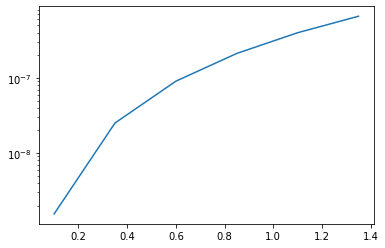

In [2]:
ddf = 1
fmin = 1.
fmax = 20000.
freqs = np.arange(fmin, fmax, ddf)

zvals = np.arange(0.1, 1.5, 0.25)

asd_t = arg.read_mag(freqs, 'curves/voyager.txt')
psd = asd_t**2

par = {
        "Mc"     : 25,
        "q"      : 1.05,
        "z"      : 1,
        "tc"     : 0.,
        "phic"   : 0.,
        "lambda" : 0., 
        "beta"   : np.pi/3., 
        "phiL"   : 0.,
        "thetaL" : np.pi / 3., # This corresponds to i = pi/6, psi = pi/2,
        "gps_t"  : 1261872018
    
    }

dpar = {
            "Mc"     : 1.e-7,
            "q"      : 1.e-7,
            "z"      : 1.e-7,
            "tc"     : 1.e-2,
            "phic"   : 1.e-7,
            "lambda" : 1.e-7,
            "beta"   : 1.e-7,
            "phiL"   : 1.e-7,
            "thetaL" : 1.e-7
        }

log_flag = {
                "Mc"     : 1.,
                "q"      : 0.,
                "z"      : 0.,
                "tc"     : 0.,
                "phic"   : 0.,
                "lambda" : 0.,
                "beta"   : 0.,
                "phiL"   : 0.,
                "thetaL" : 0.
            }

idx_par = {
        #         "Mc"     : 0,
        #         "q"      : 1,
            "z"      : 2,
            "tc"     : 3,
            "phic"   : 4,
            "lambda" : 5,
            "beta"   : 6,
            "phiL"   : 7,
            "thetaL" : 8
        }
idx_par = {key:val - 2 for (key,val) in idx_par.items() }


dets = [
    detector.Detector("H1",par["gps_t"]), 
    detector.Detector("L1",par["gps_t"]),
    detector.Detector("V1",par["gps_t"]),
    detector.Detector("K1",par["gps_t"])
    #don't have ligo india here.
]

deltaOmegas = arg.sky_loc_plot_gen(freqs, dets, zvals, par, dpar, psd, idx_par, log_flag)

plt.semilogy(zvals, deltaOmegas)